# Sin Wave Extrapolation

In [1]:
import torch
import torch.nn as nn
import numpy as np

import sys

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

/tmp/ipykernel_515/2870380934.py:9: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


## Data

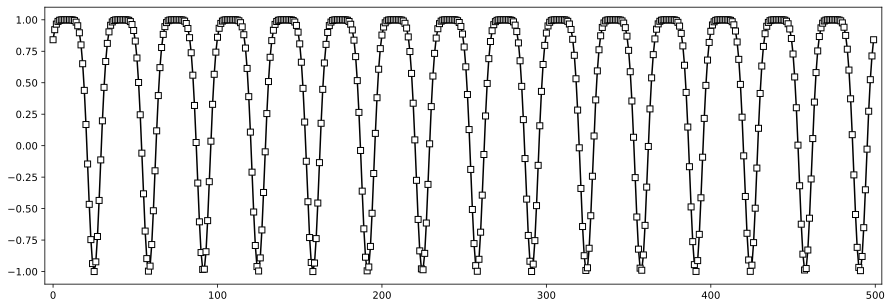

In [2]:
N = 500

time = torch.linspace(0, 30 * torch.pi, N)
data = torch.sin(time + torch.cos(time))

plt.figure(figsize = (15,5))
plt.plot(data, 'ks-', markerfacecolor = 'w')
plt.xlim([-5,N+4])
plt.show()

## Model

In [3]:
class RNNnet(nn.Module):
  def __init__(self, input_size, hidden_size, layers_num):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.layers_num = layers_num

    self.rnn = nn.RNN(self.input_size,
                      self.hidden_size,
                      self.layers_num,
                      batch_first = True)

    self.out = nn.Linear(hidden_size, 1)

  def forward(self, x, h):

    y, hidden = self.rnn(x, h)

    y = self.out(y)

    return y, hidden.detach()

## Parameters

In [4]:
input_size  = 1
hidden_size = 9
layers_num  = 1

seq_len    = 30
batch_size = 1

rnn = RNNnet(input_size, hidden_size, layers_num)

X = torch.randn(batch_size, seq_len, input_size)

y, hidden = rnn(X, None)

print('X shape:     ', X.shape)
print('y shape:     ', y.shape)
print('hidden shape:', hidden.shape)

X shape:      torch.Size([1, 30, 1])
y shape:      torch.Size([1, 30, 1])
hidden shape: torch.Size([1, 1, 9])


## Plot

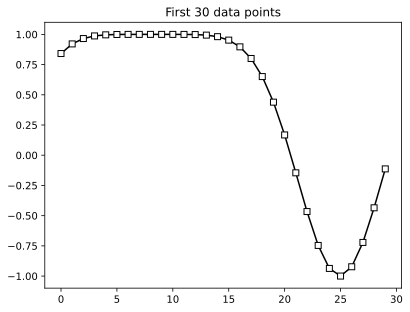

In [5]:
plt.plot(data[:seq_len], 'ks-', markerfacecolor = 'w')
plt.title(f'First {seq_len} data points')
plt.show()

## Test Model

In [6]:
some_data = data[:seq_len].view(batch_size, seq_len, input_size)
print('some_data shape:', some_data.shape)

y, h = rnn(some_data, None)

loss_fn = nn.MSELoss()
loss    = loss_fn(y[0][-1], data[seq_len].view(1,1))
print('Final Value:    ', round(loss.item(),4))

some_data shape: torch.Size([1, 30, 1])
Final Value:     0.0125


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## Train Model

In [7]:
epochs = 30

rnn = RNNnet(input_size, hidden_size, layers_num)
optimizer = torch.optim.SGD(rnn.parameters(), lr = 1e-3)

losses = torch.zeros(epochs)
sgn_accs = torch.zeros(epochs)

for epoch in range(epochs):

  # store eval
  seg_losses = torch.zeros(N-seq_len)
  seg_sgn_accs = torch.zeros(N-seq_len)

  # hidden init
  hidden_state = None

  # time loop
  for t in range(N-seq_len):

    # data
    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
    y = data[t+seq_len]

    # train
    y_hat, hidden_state = rnn(X, hidden_state)
    hidden_state = hidden_state.detach()

    # single pred
    final_pred = y_hat[0][-1]

    # loss
    loss = loss_fn(final_pred, y)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store
    seg_losses[t] = loss
    seg_sgn_accs[t] = torch.sign(final_pred) == torch.sign(y)

  # store
  losses[epoch] = torch.mean(seg_losses)
  sgn_accs[epoch] = torch.mean(seg_sgn_accs.float())

  # msg
  msg = f'Epoch {epoch+1}/{epochs}'
  sys.stdout.write('\r' + msg)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 30/30

## Plot

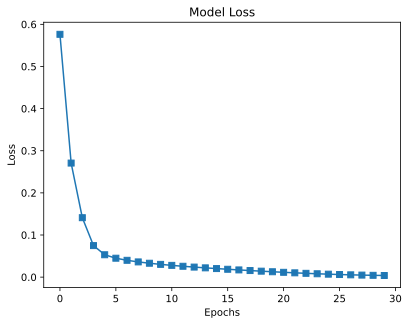

In [8]:
plt.plot(losses.detach(), 's-')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

## Test the Net

In [9]:
hidden_layers = torch.zeros((N, hidden_size))
y_hats = torch.zeros(N)

hh = None

for t in range(N-seq_len):
  X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
  y = data[t+seq_len]

  yy, hh = rnn(X, hh)

  y_hat = yy[0][-1]
  y_hats[t+seq_len] = y_hat
  hidden_layers[t,:] = hh.detach()

## Plot

### General

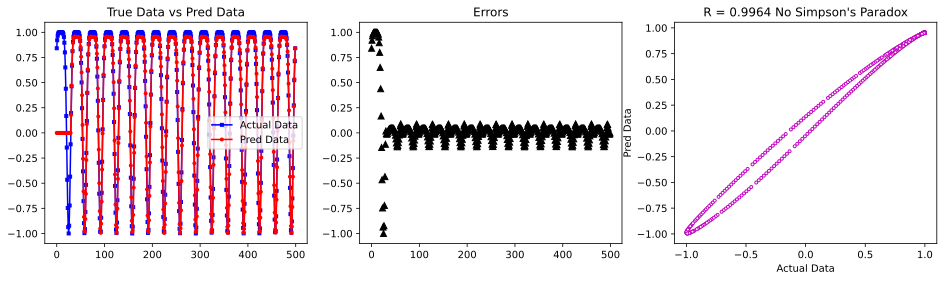

In [10]:
fig, axs = plt.subplots(1,3,figsize = (16,4))

axs[0].plot(data, 'bs-', markersize = 3, label = 'Actual Data')
axs[0].plot(y_hats.detach(), 'ro-', markersize = 3, label = 'Pred Data')
axs[0].set_title('True Data vs Pred Data')
axs[0].set_ylim([-1.1,1.1])
axs[0].legend()

axs[1].plot(data - y_hats.detach(), 'k^')
axs[1].set_title('Errors')
axs[1].set_ylim([-1.1,1.1])

axs[2].plot(data[seq_len:], y_hats[seq_len:].detach(), 'mo', markerfacecolor = 'w', markersize = 3)
axs[2].set_xlabel('Actual Data')
axs[2].set_ylabel('Pred Data')
r = np.corrcoef(data[seq_len:], y_hats[seq_len:].detach())
axs[2].set_title(f'R = {r[0,1]:.4f} No Simpson\'s Paradox')

plt.show()

### Hidden States

Text(0.5, 1.0, 'Each line is a different hidden')

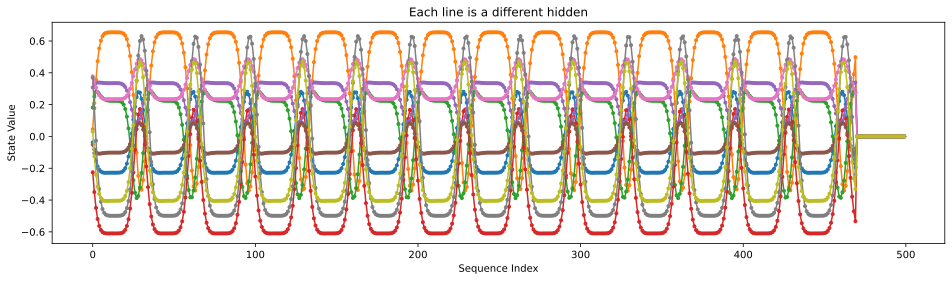

In [11]:
plt.figure(figsize=(16,4))

plt.plot(hidden_layers, 'o-', markersize = 3)
plt.xlabel('Sequence Index')
plt.ylabel('State Value')
plt.title('Each line is a different hidden')

### Weights

 plot the weights for the input->hidden layers

In [ ]:
plt.bar(range(hidden_size), rnn.rnn.weight_ih_l0[:,0].detach())
plt.ylabel('Weight value')
plt.show()

## Test Data

In [12]:
def run_experiment(data):
  # loop over time and predict each subsequent value
  y_hats = torch.zeros(N)
  hh = None
  h = torch.zeros((N, hidden_size))

  for t in range(N-seq_len):

    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)

    yy, hh = rnn(X, hh)
    hh = hh.detach()
    y_hats[t + seq_len] = yy[0][-1].item()
    # h[t + seq_len,:] = hh[-1, 0, :].detach()
    h[t + seq_len,:] = hh.detach()

  fig, axs = plt.subplots(1,3,figsize = (16,4))

  axs[0].plot(data, 'bs-', markersize = 3, label = 'Actual Data')
  axs[0].plot(y_hats.detach(), 'ro-', markersize = 3, label = 'Pred Data')
  axs[0].set_title('True Data vs Pred Data')
  axs[0].set_ylim([-1.1,1.1])
  axs[0].legend()

  axs[1].plot(data - y_hats.detach(), 'k^')
  axs[1].set_title('Errors')
  axs[1].set_ylim([-1.1,1.1])

  axs[2].plot(data[seq_len:], y_hats[seq_len:].detach(), 'mo', markerfacecolor = 'w', markersize = 3)
  axs[2].set_xlabel('Actual Data')
  axs[2].set_ylabel('Pred Data')
  r = np.corrcoef(data[seq_len:], y_hats[seq_len:].detach())
  axs[2].set_title(f'R = {r[0,1]:.4f} No Simpson\'s Paradox')

  plt.show()

### $\text{sin(time + cos(time))},\; t\in(0,30\pi)$

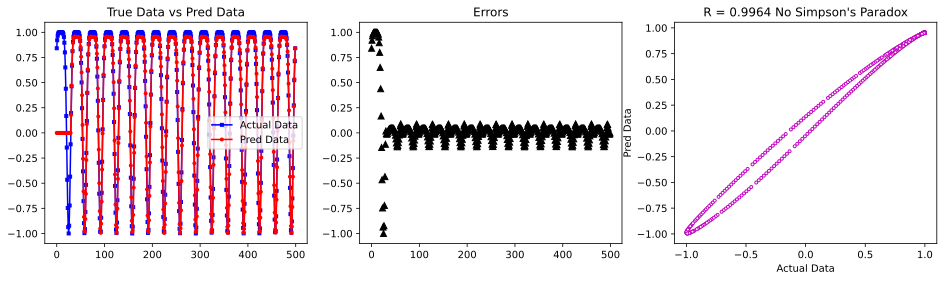

In [13]:
# Create new data (orange case: different frequency)
time = torch.linspace(0, 30*np.pi, N)
new_data = torch.sin(time + torch.cos(time))

run_experiment(new_data)

### $\text{sin(time + cos(time))},\; t\in(0,10\pi)$

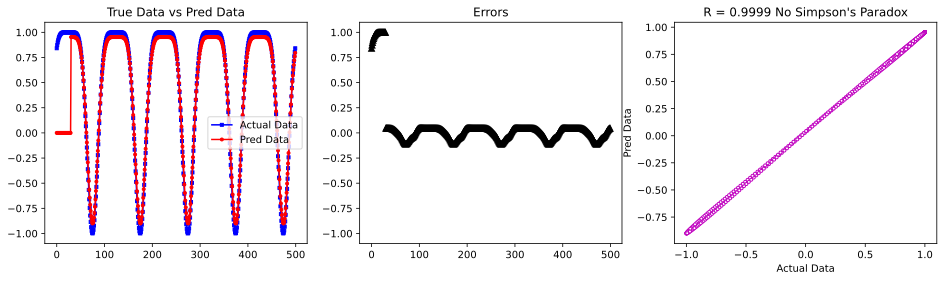

In [14]:
time = torch.linspace(0,10*np.pi,N)
new_data = torch.sin(time + torch.cos(time))

run_experiment(new_data)

### $\text{sin(time + sin(time))},\; t\in(0,30\pi)$

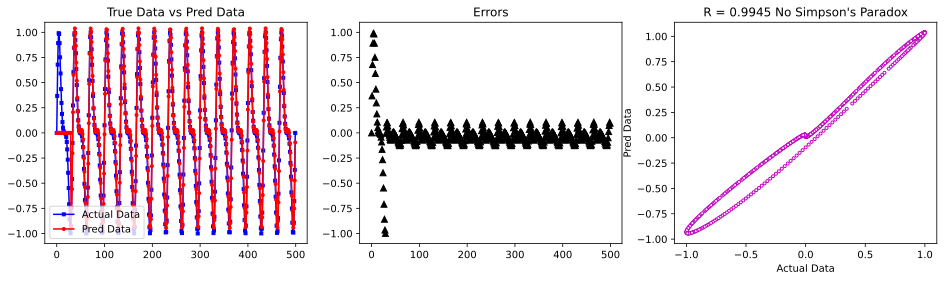

In [15]:
time = torch.linspace(0,30*np.pi,N)
new_data = torch.sin(time + torch.sin(time))

run_experiment(new_data)

## Longer-Term Extrapolation

### Prepare

Same data and model as original

In [16]:
############
### Data ###
############

N = 500

time = torch.linspace(0, 30 * torch.pi, N)
data = torch.sin(time + torch.cos(time))

#############
### Model ###
#############

class RNNnet(nn.Module):
  def __init__(self, input_size, hidden_size, layers_num):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.layers_num = layers_num

    self.rnn = nn.RNN(self.input_size,
                      self.hidden_size,
                      self.layers_num,
                      batch_first = True)

    self.out = nn.Linear(hidden_size, 1)

  def forward(self, x, h):

    y, hidden = self.rnn(x, h)

    y = self.out(y)

    return y, hidden.detach()

##################
### MODEL INIT ###
##################

input_size  = 1
hidden_size = 9
layers_num  = 1

seq_len    = 30
batch_size = 1

rnn = RNNnet(input_size, hidden_size, layers_num)

X = torch.randn(batch_size, seq_len, input_size)

y, hidden = rnn(X, None)

#############
### TRAIN ###
#############

epochs = 30

rnn = RNNnet(input_size, hidden_size, layers_num)
optimizer = torch.optim.SGD(rnn.parameters(), lr = 1e-3)

losses = torch.zeros(epochs)
sgn_accs = torch.zeros(epochs)

for epoch in range(epochs):

  # store eval
  seg_losses = torch.zeros(N-seq_len)
  seg_sgn_accs = torch.zeros(N-seq_len)

  # hidden init
  hidden_state = None

  # time loop
  for t in range(N-seq_len):

    # data
    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
    y = data[t+seq_len]

    # train
    y_hat, hidden_state = rnn(X, hidden_state)
    hidden_state = hidden_state.detach()

    # single pred
    final_pred = y_hat[0][-1]

    # loss
    loss = loss_fn(final_pred, y)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store
    seg_losses[t] = loss
    seg_sgn_accs[t] = torch.sign(final_pred) == torch.sign(y)

  # store
  losses[epoch] = torch.mean(seg_losses)
  sgn_accs[epoch] = torch.mean(seg_sgn_accs.float())

  # msg
  msg = f'Epoch {epoch+1}/{epochs}'
  sys.stdout.write('\r' + msg)

Epoch 30/30

### Extrapolation

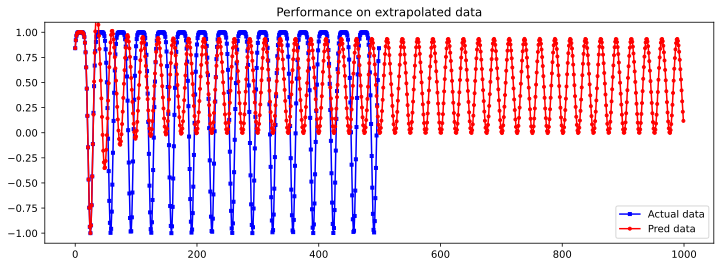

In [17]:
y_hat = torch.zeros(2*N)
y_hat[:N] = data
hidden = None

for t in range(2*N-seq_len):

  X = y_hat[t:t+seq_len].view(batch_size, seq_len, input_size)

  yy, hidden = rnn(X, hidden)
  # hidden = hidden.detach()
  y_hat[t+seq_len] = yy[0,-1,0]

y_hat = y_hat.detach()

fig = plt.figure(figsize=(12,4))
plt.plot(data,  'bs-', label = 'Actual data',markersize =3)
plt.plot(y_hat, 'ro-', label = 'Pred data',  markersize = 3)
plt.ylim([-1.1,1.1])
plt.legend()
plt.title('Performance on extrapolated data')
plt.show()